In [12]:
import os
import json
import pandas as pd


In [13]:
path = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics"
folders = os.listdir(path)
folders = [f for f in folders if f.startswith("train")]

In [16]:
folders = ["no_train", "train"]
for i in range(2,11):
    folders.append(f"train{i}")
folders

['no_train',
 'train',
 'train2',
 'train3',
 'train4',
 'train5',
 'train6',
 'train7',
 'train8',
 'train9',
 'train10']

In [17]:

all_rows = []  # collect rows
indices = []   # collect folder names

for folder in folders:
    file = os.path.join(path, folder, "metrics.json")
    with open(file, "r") as f:
        data = json.load(f)
    
    # Extract precision, recall, and compute F1 for each class
    flat = {}
    for cls, metrics in data["per_class"].items():
        precision = metrics["precision"]
        recall = metrics["recall"]
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        flat[f"class{cls}_precision"] = precision
        flat[f"class{cls}_recall"] = recall
        flat[f"class{cls}_f1"] = f1

    all_rows.append(flat)
    indices.append(folder)

# Build final DataFrame
df = pd.DataFrame(all_rows, index=indices)

print(df)


          class0_precision  class0_recall  class0_f1  class1_precision  \
no_train          0.787760       0.491870   0.605606          0.879945   
train             0.742292       0.594680   0.660338          0.851852   
train2            0.740126       0.593414   0.658699          0.689869   
train3            0.737405       0.611780   0.668744          0.852691   
train4            0.828681       0.545282   0.657754          0.885000   
train5            0.787736       0.634579   0.702911          0.770115   
train6            0.780545       0.635212   0.700419          0.885396   
train7            0.757392       0.632679   0.689441          0.832487   
train8            0.753698       0.645345   0.695326          0.860422   
train9            0.815769       0.661811   0.730769          0.776018   
train10           0.704602       0.717543   0.711013          0.856128   

          class1_recall  class1_f1  class3_precision  class3_recall  class3_f1  
no_train       0.576923   0.69

In [18]:
# Find row name (index) with max per column
max_row = df.idxmax()

# Add as new row
df.loc["max_row"] = max_row

print(df)

         class0_precision class0_recall class0_f1 class1_precision  \
no_train          0.78776       0.49187  0.605606         0.879945   
train            0.742292       0.59468  0.660338         0.851852   
train2           0.740126      0.593414  0.658699         0.689869   
train3           0.737405       0.61178  0.668744         0.852691   
train4           0.828681      0.545282  0.657754            0.885   
train5           0.787736      0.634579  0.702911         0.770115   
train6           0.780545      0.635212  0.700419         0.885396   
train7           0.757392      0.632679  0.689441         0.832487   
train8           0.753698      0.645345  0.695326         0.860422   
train9           0.815769      0.661811  0.730769         0.776018   
train10          0.704602      0.717543  0.711013         0.856128   
max_row            train4       train10    train9           train6   

         class1_recall class1_f1 class3_precision class3_recall class3_f1  
no_train     

confusion matrices

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [7]:
def create_confusion_matrix(data, species):
    """
    Creates a confusion matrix from detection results using GT derived from filename.

    Args:
        data: list of results entries from results.json
        species: list of species names in order of class indices

    Returns:
        cm: (num_classes + 1) x (num_classes + 1) confusion matrix
            Rows = ground truth classes
            Columns = predicted classes
            Last row = background FP
            Last column = missed GT (FN)
    """
    num_classes = len(species)
    cm = np.zeros((num_classes + 1, num_classes + 1), dtype=int)

    for entry in data:
        filename = entry["filename"]
        # Derive GT class from filename; fallback to last index if unknown
        row_index = next((i for i, sp in enumerate(species) if filename.startswith(sp)), num_classes)

        # True positives (correct predictions)
        for cls_id in entry["true_positives"]["classes"]:
            cm[row_index, cls_id] += 1

        # False negatives (missed GT objects)
        cm[row_index, num_classes] += len(entry["false_negatives"]["classes"])

        # False positives
        for cls_id in entry["false_positives"]["classes"]:
            if cls_id == row_index:
                # Background FP (wrong location for correct class)
                cm[num_classes, cls_id] += 1
            else:
                # Misclassification (wrong class)
                cm[row_index, cls_id] += 1

    return cm

def normalize_confusion_matrix(cm, axis=1):
    """
    Normalize a confusion matrix.

    Parameters
    ----------
    cm : list[list[int]] or np.ndarray
        The confusion matrix.
    axis : int
        Axis to normalize over:
        - 1 = rows (normalize by true class → each row sums to 1)
        - 0 = columns (normalize by predicted class → each column sums to 1)
        - None = normalize by total sum

    Returns
    -------
    np.ndarray
        Normalized confusion matrix (float values).
    """
    cm = np.array(cm, dtype=float)
    if axis is None:
        total = cm.sum()
        return cm / total if total > 0 else cm
    else:
        sums = cm.sum(axis=axis, keepdims=True)
        sums[sums == 0] = 1 
 # avoid division by zero
        return cm / sums
    
def plot_confusion_matrix(cm, species):

    # assume confusion_matrix and labels are already defined
    labels = species + ["background"]
    df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=(8, 6))
    plt.imshow(df, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()

    # tick labels
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)

    # annotate counts
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, df.iat[i, j],
                    ha="center", va="center",
                    color="white" if df.iat[i, j] > df.values.max()/2 else "black")

    plt.ylabel("True Species")
    plt.xlabel("Predicted Species")
    plt.tight_layout()
    plt.show()


import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def give_confusion_infos(file):
    with open(file, "r") as f:
        data = json.load(f)

    species = ["BRAIIM", "LIRIBO", "FRANOC", "TRIAVA"]
    cm = create_confusion_matrix(data, species)

    print("Confusion Matrix with FP/FN (last row = FP, last col = FN):\n", cm)

    # Row-normalized (recall per class)
    norm_cm_row = normalize_confusion_matrix(cm, axis=1)
    # Column-normalized (precision per class)
    norm_cm_col = normalize_confusion_matrix(cm, axis=0)

    labels = species + ["background"]

    # ✅ use constrained_layout to avoid tight_layout warning
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for ax, norm_cm, title in zip(
        axes,
        [norm_cm_row, norm_cm_col],
        ["Row-normalized (Recall per class)", "Column-normalized (Precision per class)"]
    ):
        df = pd.DataFrame(np.round(norm_cm, 2), index=labels, columns=labels)
        im = ax.imshow(df, interpolation="nearest", cmap="Blues")
        ax.set_title(title)
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_ylabel("True Species")
        ax.set_xlabel("Predicted Species")

        # annotate cells
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(
                    j, i, f"{df.iat[i, j]:.2f}",
                    ha="center", va="center",
                    color="white" if df.iat[i, j] > df.values.max()/2 else "black",
                    fontsize=8
                )

    # shared colorbar (works fine with constrained_layout)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Normalized Value")
    plt.show()
    return norm_cm_row, norm_cm_col


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_confusion_matrix_differences(norm_cm_row_1, norm_cm_row_2,
                                      norm_cm_col_1, norm_cm_col_2,
                                      species):
    """
    Plot the differences between two sets of normalized confusion matrices
    (row- and column-normalized) with intuitive coloring:

    - Diagonal ↑ = green (improvement), ↓ = red (worse)
    - Off-diagonal ↑ = red (worse), ↓ = green (improvement)
    - Color range automatically scaled to actual data range
    """

    labels = species + ["background"]

    # Compute differences
    diff_row = np.round(norm_cm_row_2 - norm_cm_row_1, 3)
    diff_col = np.round(norm_cm_col_2 - norm_cm_col_1, 3)

    # Make figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for ax, diff_cm, title in zip(
        axes,
        [diff_row, diff_col],
        ["Δ Row-normalized (Recall change)", "Δ Column-normalized (Precision change)"]
    ):
        df = pd.DataFrame(diff_cm, index=labels, columns=labels)

        # Invert off-diagonal meaning (since increases in misclassifications are bad)
        adjusted = df.copy()
        for i in range(len(labels)):
            for j in range(len(labels)):
                if i != j:
                    adjusted.iat[i, j] = -adjusted.iat[i, j]

        # Compute color limits dynamically
        vmin, vmax = adjusted.values.min(), adjusted.values.max()
        vlim = max(abs(vmin), abs(vmax))  # symmetric around zero

        # Use a centered diverging colormap: red↔white↔green
        norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)
        im = ax.imshow(adjusted, interpolation="nearest", cmap="RdYlGn", norm=norm)

        ax.set_title(title)
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_ylabel("True Species")
        ax.set_xlabel("Predicted Species")

        # Annotate numeric values (+/-)
        for i in range(len(labels)):
            for j in range(len(labels)):
                val = df.iat[i, j]
                if abs(val) > 0.005:
                    ax.text(
                        j, i, f"{val:+.2f}",
                        ha="center", va="center",
                        color="black",
                        fontsize=8
                    )

    # Shared colorbar
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("Green = improvement, Red = degradation", rotation=270, labelpad=20)
    plt.show()


species = ["BRAIIM", "LIRIBO", "FRANOC", "TRIAVA"]


### Quality of image processed pseudo labels

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 605    0    0    0  625]
 [   0  645    0    0  473]
 [   0    0    0    0    0]
 [   0    0    0  822 1615]
 [ 163   88    0  194    0]]


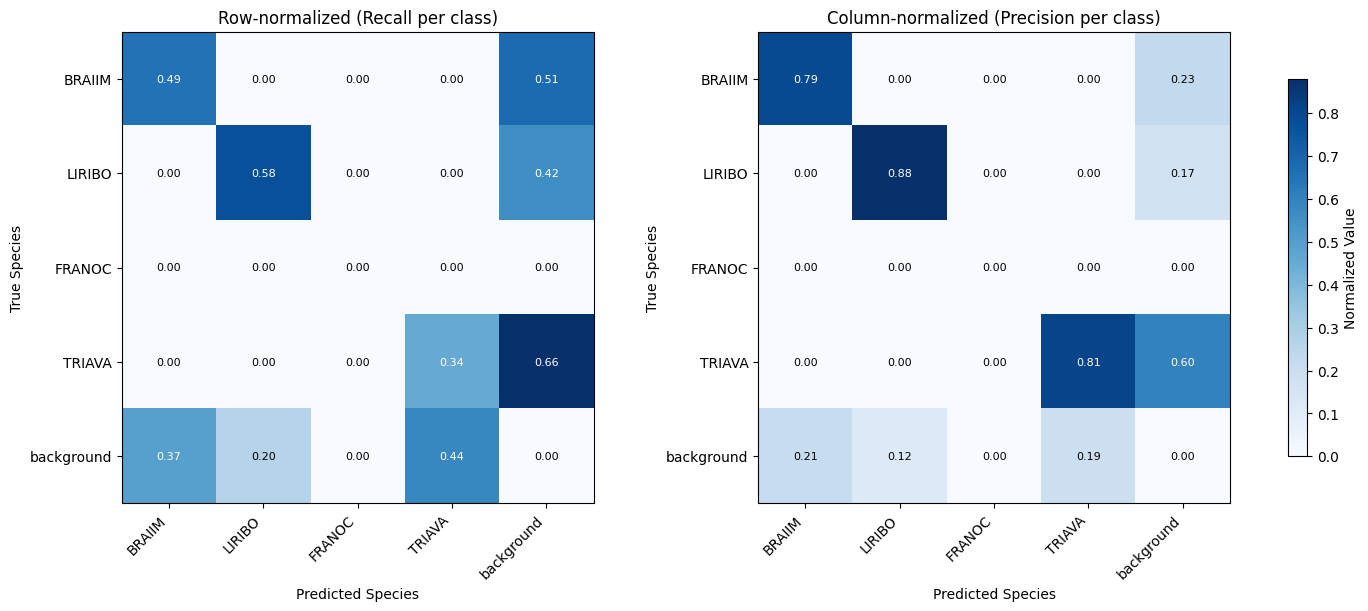

In [8]:
#Test image processing on test set
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/no_train/results.json"
c1, c2 = give_confusion_infos(file)

### Quality of model trained on these pseudo labels against ground truth


Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1045   63    0    0  534]
 [  41 1029    0    5  230]
 [   0    0    0    0    0]
 [   5   42    0  771 1850]
 [ 190  192    0   36    0]]


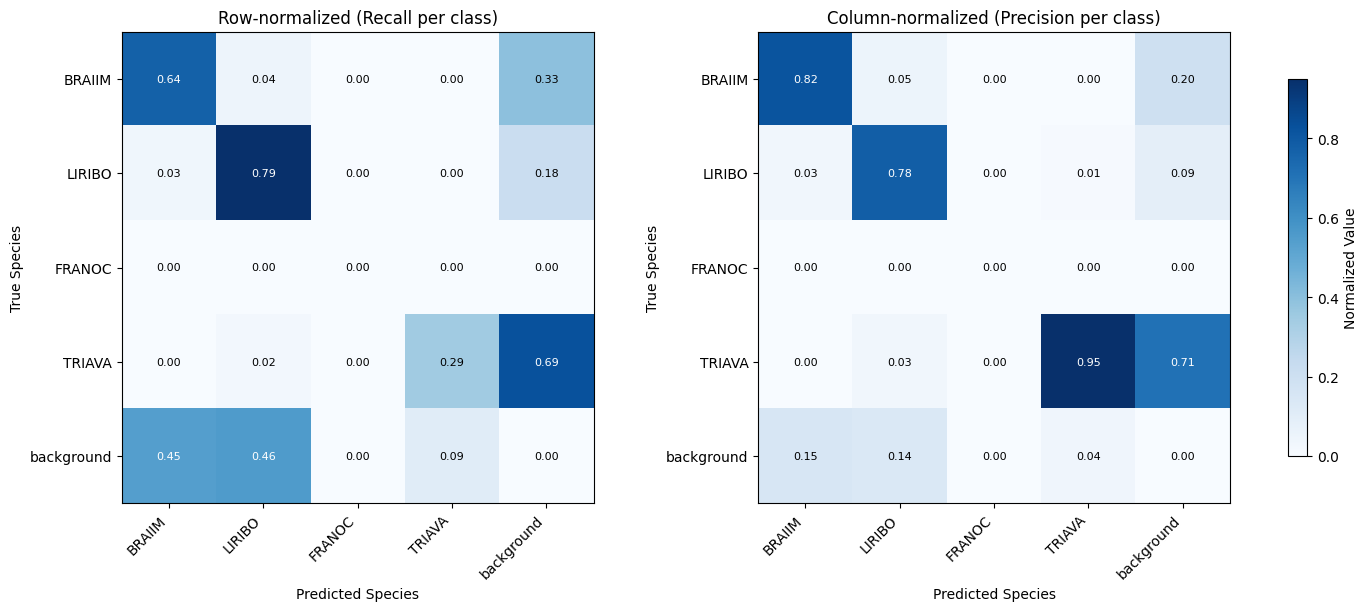

In [9]:
#test results of first iteration
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train9/results.json"
c3, c4 = give_confusion_infos(file)

### Quality of model compared to image processed test set labels

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[665  60   0   0 103]
 [ 38 669   0   4  64]
 [  0   0   0   0   0]
 [  6  48   0 436 580]
 [415 422   0 255   0]]


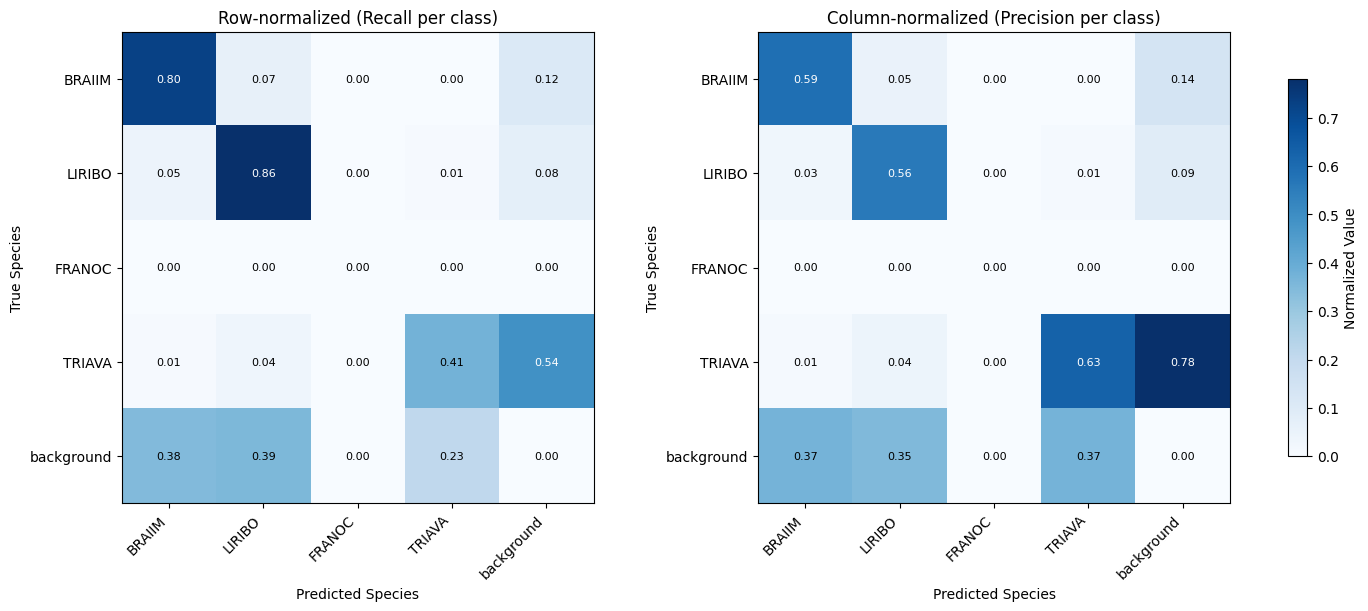

In [10]:
#test results of first iteration
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train9_pseudolabeltest/results.json"
c5, c6 = give_confusion_infos(file)

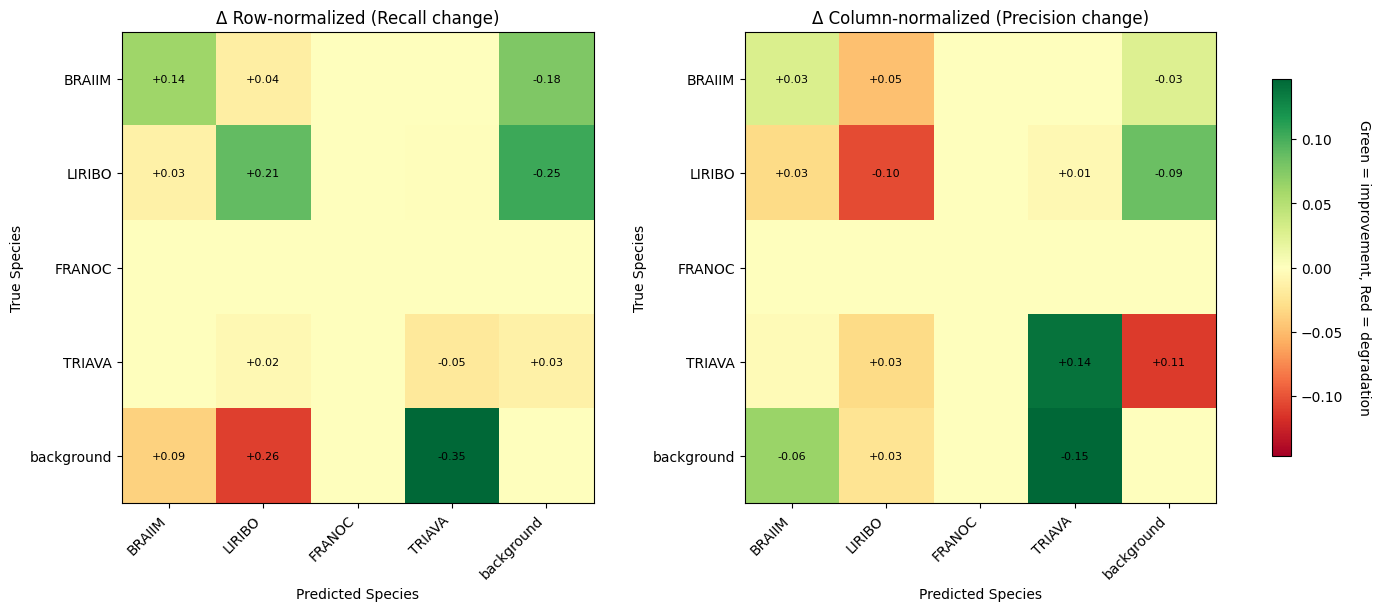

In [26]:
#Difference of segmented labels and first training
plot_confusion_matrix_differences(c1,c3, c2, c4, species)

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 927   26    0    1  652]
 [  29  893    0    7  366]
 [   0    0    0    0    0]
 [   5   10    0  647 1974]
 [ 206  156    0   45    0]]


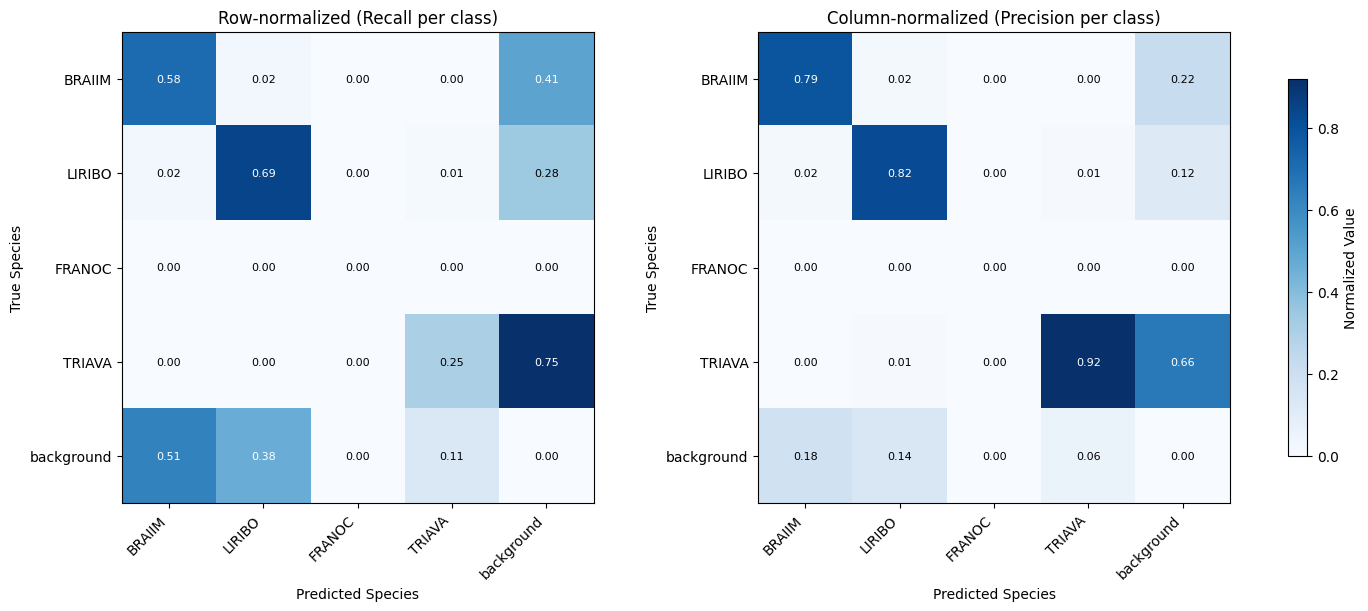

In [21]:
#test results of second iteration
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/results_train5.json"
c5,c6 = give_confusion_infos(file)

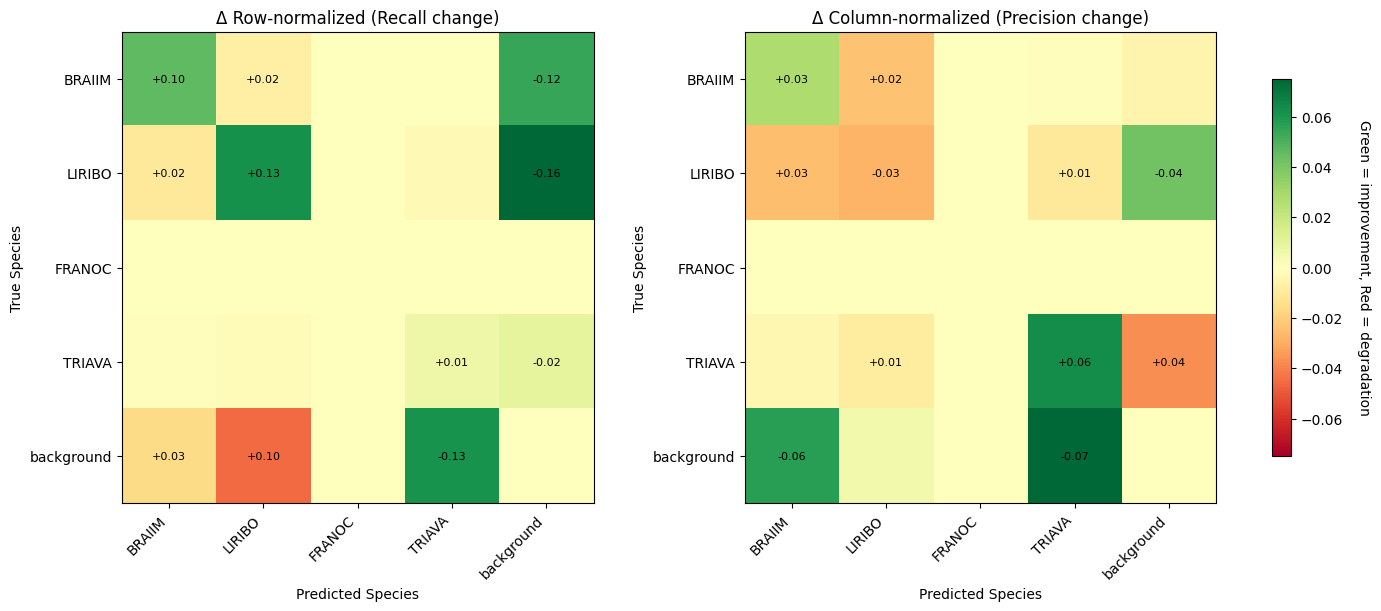

In [22]:
#Difference of segmented labels and second training
plot_confusion_matrix_differences(c1,c5, c2, c6, species)


train5 and first run of the following should be identical

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 854    7    0    1  725]
 [  26  848    0    8  411]
 [   0    0    0    0    0]
 [   4    7    0  648 1973]
 [ 177  119    0   45    0]]


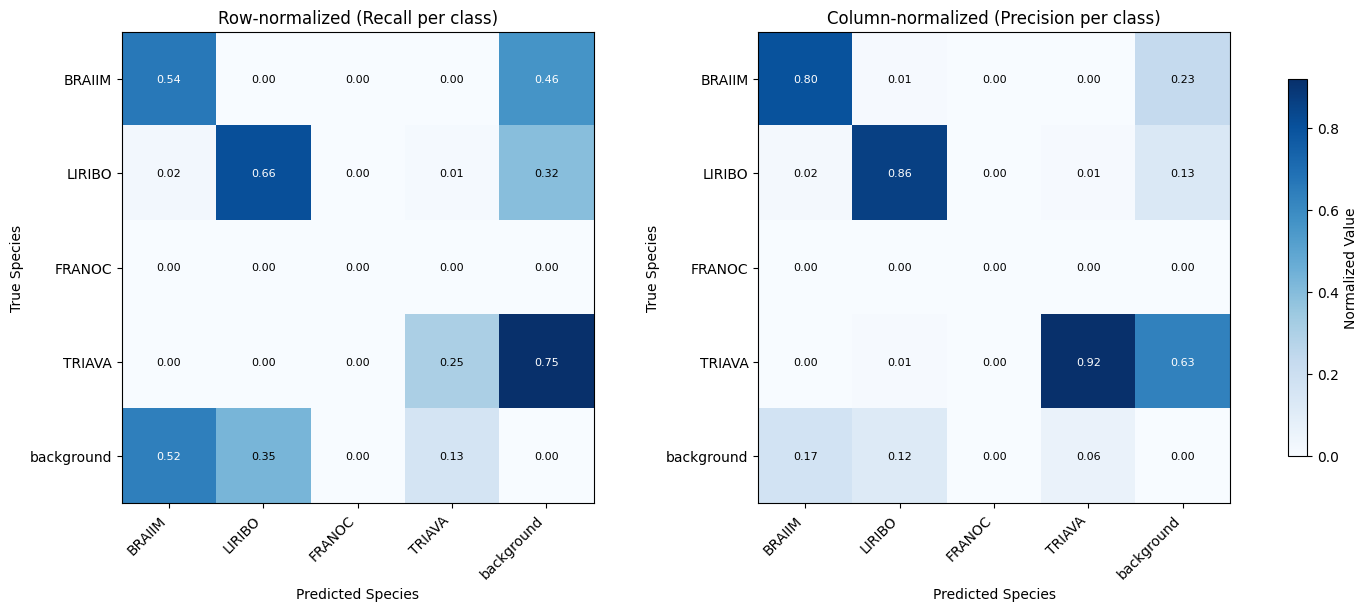

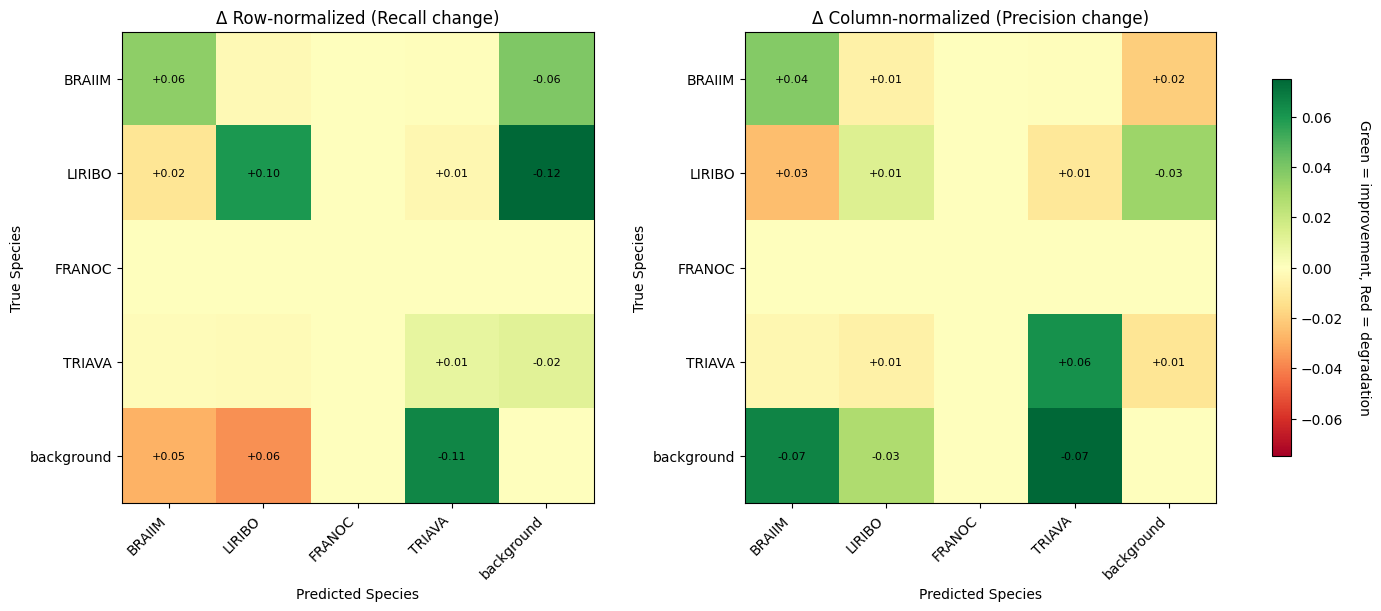

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 942    8    0    1  637]
 [  40  872    0    6  387]
 [   0    0    0    0    0]
 [  10    6    0  667 1954]
 [ 222  144    0   45    0]]


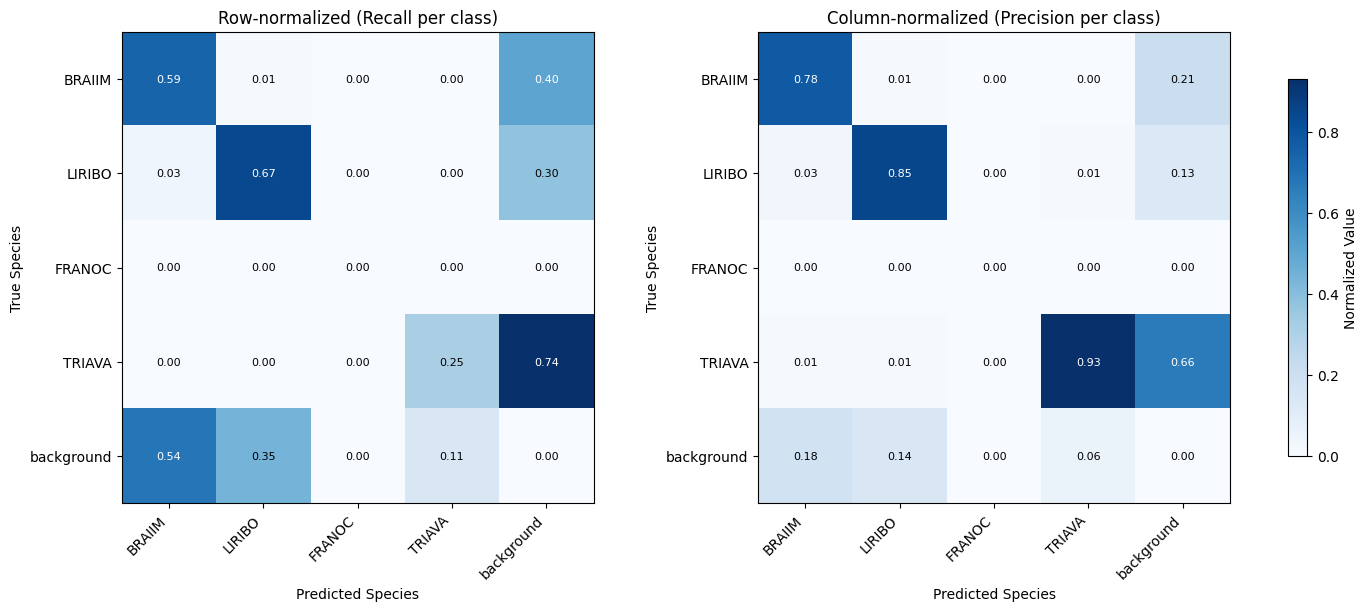

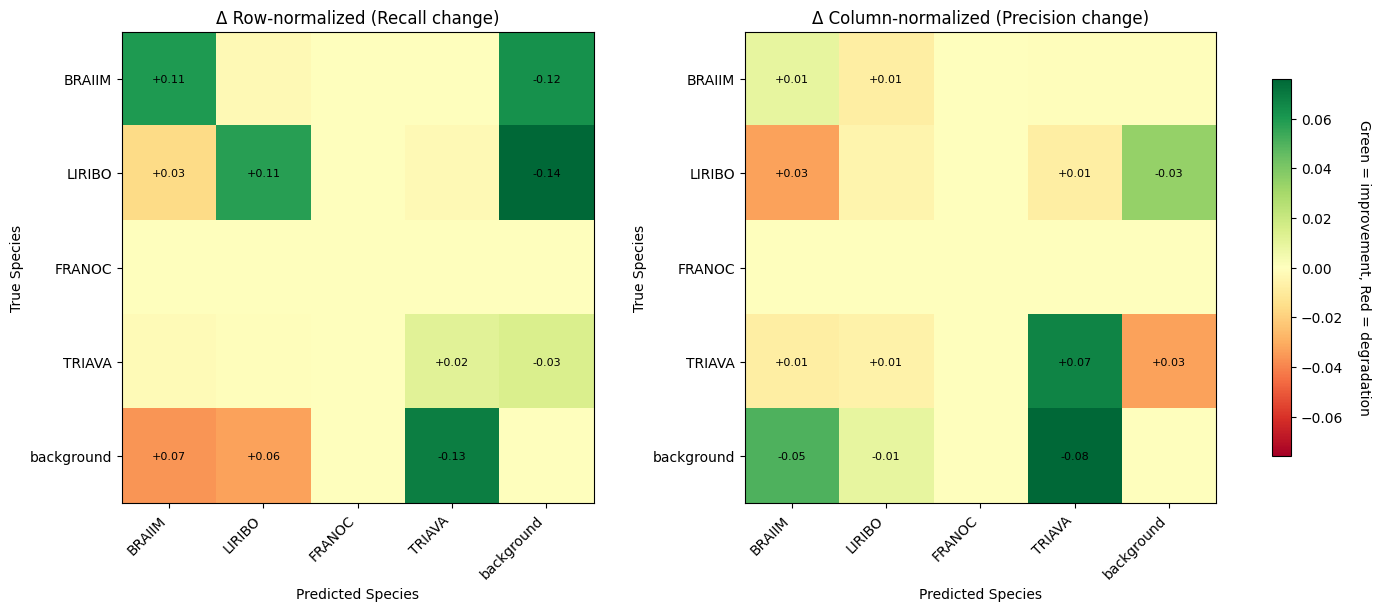

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 986   12    0    1  593]
 [  44  923    0   12  336]
 [   0    0    0    0    0]
 [  13   14    0  688 1933]
 [ 242  144    0   60    0]]


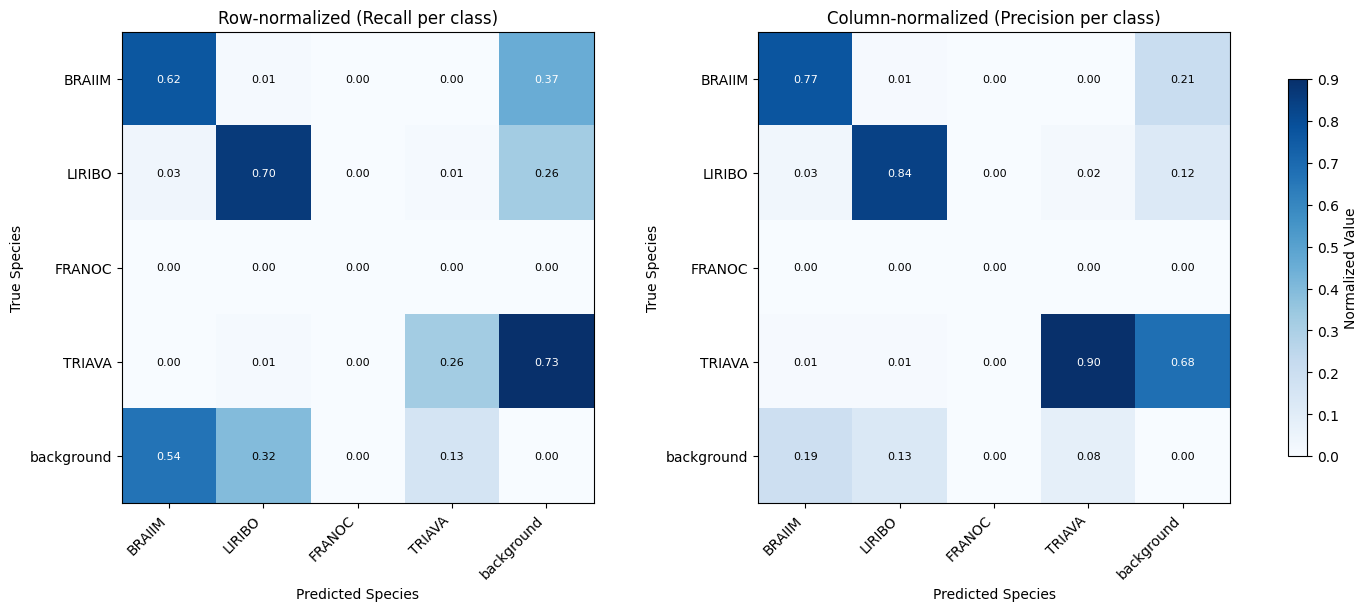

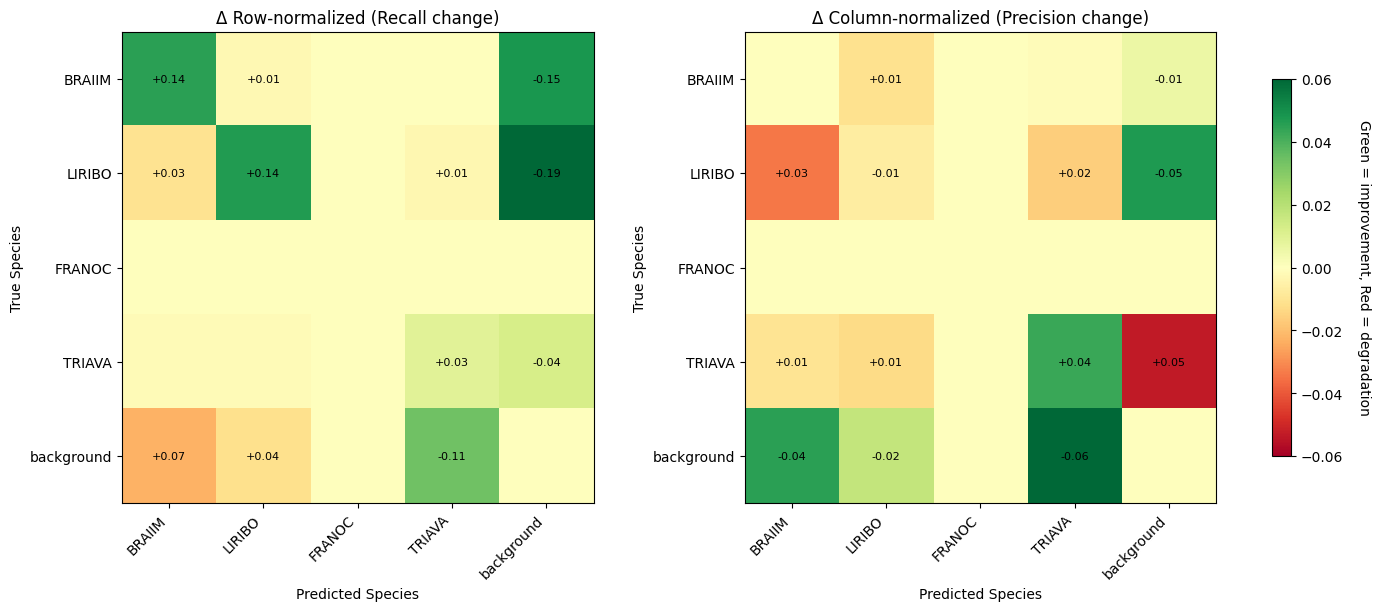

In [23]:
#for three runs 10 epochs, threshold 0.6
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/10epochs06/train2/results.json"
c3,c4 = give_confusion_infos(file)
plot_confusion_matrix_differences(c1,c3, c2, c4, species)
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/10epochs06/train3/results.json"
c3,c4 = give_confusion_infos(file)
plot_confusion_matrix_differences(c1,c3, c2, c4, species)
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/10epochs06/train4/results.json"
c3,c4 = give_confusion_infos(file)
plot_confusion_matrix_differences(c1,c3, c2, c4, species)